In [4]:
import pandas as pd
import geopandas as gpd


enc = 'utf-8'

In [10]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [9]:
greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

In [11]:
nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
21,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL521,Imathia,Ημαθία,2.0,2,1,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
22,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL522,Thessaloniki,Θεσσαλονίκη,2.0,1,1,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
23,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL523,Kilkis,Κιλκίς,4.0,3,2,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
25,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL525,Pieria,Πιερία,4.0,2,1,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."


In [12]:
nuts2_gdf = nuts2_gdf.to_crs(epsg=4326)

In [13]:
nuts2_grid = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding = enc)
nuts2_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.96176,40.52441
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.56484
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.60526
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.64569
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.27979,40.40314
...,...,...,...,...,...,...
642,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.37360
643,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.33318
644,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.09062
645,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.55751,39.96935


In [14]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y), crs=4326)
nuts2_grid_points

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,geometry
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.96176,40.52441,POINT (21.96176 40.52441)
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.56484,POINT (22.22679 40.56484)
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.60526,POINT (22.22679 40.60526)
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.64569,POINT (22.22679 40.64569)
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.27979,40.40314,POINT (22.27979 40.40314)
...,...,...,...,...,...,...,...
642,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.37360,POINT (23.39941 40.37360)
643,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.33318,POINT (23.39941 40.33318)
644,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.09062,POINT (23.39941 40.09062)
645,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.55751,39.96935,POINT (23.55751 39.96935)


In [15]:
geo = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geo

,x,y,DISTANCE_TO_COAST,DISTANCE_TO_RIVER,SLOPE_mean_1km,ASPECT_mean_200m,ELEVATION_mean_1km,HILLSHADE_mean_1km,FS_AREA_1km,FLOW_ACCU_200m
0,24.05105,40.31951,2802.421393,4354.991527,14,231.417467,276.517281,188.889456,0.000000,3.998248
1,24.05105,40.35544,1849.716366,697.392287,26,127.358018,145.408143,163.763939,0.000000,2.006094
2,24.09803,40.31951,3388.512883,5473.471255,13,192.256866,239.376381,181.658242,0.000000,3.609011
3,24.30947,40.15781,2116.919637,4867.646762,44,285.956649,945.458571,240.592577,0.000000,3.887520
4,21.83449,40.75699,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672
...,...,...,...,...,...,...,...,...,...,...
179,22.89198,40.65603,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007
180,22.95369,40.62334,239.472007,2110.018302,8,175.716890,17.195550,184.189975,0.828767,28.165350
181,22.95724,40.57876,838.915692,2171.622598,3,212.143062,39.965227,183.807590,0.037791,1.964615
182,22.90326,40.67609,3403.983637,1669.776049,5,194.345828,53.352587,183.436049,0.000000,4.846269


In [19]:
geo_points = gpd.GeoDataFrame(geo, geometry=gpd.points_from_xy(geo.x, geo.y), crs=4326)
geo_points


,x,y,DISTANCE_TO_COAST,DISTANCE_TO_RIVER,SLOPE_mean_1km,ASPECT_mean_200m,ELEVATION_mean_1km,HILLSHADE_mean_1km,FS_AREA_1km,FLOW_ACCU_200m,geometry
0,24.05105,40.31951,2802.421393,4354.991527,14,231.417467,276.517281,188.889456,0.000000,3.998248,POINT (24.05105 40.31951)
1,24.05105,40.35544,1849.716366,697.392287,26,127.358018,145.408143,163.763939,0.000000,2.006094,POINT (24.05105 40.35544)
2,24.09803,40.31951,3388.512883,5473.471255,13,192.256866,239.376381,181.658242,0.000000,3.609011,POINT (24.09803 40.31951)
3,24.30947,40.15781,2116.919637,4867.646762,44,285.956649,945.458571,240.592577,0.000000,3.887520,POINT (24.30947 40.15781)
4,21.83449,40.75699,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.000000,1.059672,POINT (21.83449 40.75699)
...,...,...,...,...,...,...,...,...,...,...,...
179,22.89198,40.65603,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,POINT (22.89198 40.65603)
180,22.95369,40.62334,239.472007,2110.018302,8,175.716890,17.195550,184.189975,0.828767,28.165350,POINT (22.95369 40.62334)
181,22.95724,40.57876,838.915692,2171.622598,3,212.143062,39.965227,183.807590,0.037791,1.964615,POINT (22.95724 40.57876)
182,22.90326,40.67609,3403.983637,1669.776049,5,194.345828,53.352587,183.436049,0.000000,4.846269,POINT (22.90326 40.67609)


In [17]:
lc = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
lc

,x,y,2001_01_01_LC_Prop1,2001_01_01_LC_Prop1_Assessment,2001_01_01_LC_Prop2,2001_01_01_LC_Prop2_Assessment,2001_01_01_LC_Prop3,2001_01_01_LC_Prop3_Assessment,2001_01_01_LC_Type1,2001_01_01_LC_Type2,...,2023_01_01_LC_Prop2_Assessment,2023_01_01_LC_Prop3,2023_01_01_LC_Prop3_Assessment,2023_01_01_LC_Type1,2023_01_01_LC_Type2,2023_01_01_LC_Type3,2023_01_01_LC_Type4,2023_01_01_LC_Type5,2023_01_01_LW,2023_01_01_QC
0,24.05105,40.31951,11,82,10,81.0,10,81,1,1,...,91.0,20,91,8,8,4,1,1,2,0
1,24.05105,40.35544,12,76,10,85.0,10,85,2,2,...,99.0,10,99,2,2,5,2,2,2,0
2,24.09803,40.31951,21,73,20,73.0,20,73,8,8,...,91.0,20,91,8,8,4,1,1,2,0
3,24.30947,40.15781,11,61,10,74.0,27,58,11,1,...,77.0,20,77,8,8,4,1,1,2,0
4,21.83449,40.75699,31,85,30,85.0,30,85,10,10,...,95.0,30,95,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,22.89198,40.65603,32,89,9,97.0,30,89,13,13,...,99.0,30,97,13,13,10,8,9,2,0
180,22.95369,40.62334,32,83,9,91.0,30,83,13,13,...,97.0,30,96,13,13,10,8,9,2,0
181,22.95724,40.57876,32,91,9,96.0,30,91,13,13,...,99.0,30,98,13,13,10,8,9,2,0
182,22.90326,40.67609,32,76,9,71.0,30,76,13,13,...,99.0,30,97,13,13,10,8,9,2,0


In [18]:
lc_points = gpd.GeoDataFrame(lc, geometry=gpd.points_from_xy(lc.x, lc.y), crs=4326)
lc_points

,x,y,2001_01_01_LC_Prop1,2001_01_01_LC_Prop1_Assessment,2001_01_01_LC_Prop2,2001_01_01_LC_Prop2_Assessment,2001_01_01_LC_Prop3,2001_01_01_LC_Prop3_Assessment,2001_01_01_LC_Type1,2001_01_01_LC_Type2,...,2023_01_01_LC_Prop3,2023_01_01_LC_Prop3_Assessment,2023_01_01_LC_Type1,2023_01_01_LC_Type2,2023_01_01_LC_Type3,2023_01_01_LC_Type4,2023_01_01_LC_Type5,2023_01_01_LW,2023_01_01_QC,geometry
0,24.05105,40.31951,11,82,10,81.0,10,81,1,1,...,20,91,8,8,4,1,1,2,0,POINT (24.05105 40.31951)
1,24.05105,40.35544,12,76,10,85.0,10,85,2,2,...,10,99,2,2,5,2,2,2,0,POINT (24.05105 40.35544)
2,24.09803,40.31951,21,73,20,73.0,20,73,8,8,...,20,91,8,8,4,1,1,2,0,POINT (24.09803 40.31951)
3,24.30947,40.15781,11,61,10,74.0,27,58,11,1,...,20,77,8,8,4,1,1,2,0,POINT (24.30947 40.15781)
4,21.83449,40.75699,31,85,30,85.0,30,85,10,10,...,30,95,10,10,1,6,6,2,0,POINT (21.83449 40.75699)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,22.89198,40.65603,32,89,9,97.0,30,89,13,13,...,30,97,13,13,10,8,9,2,0,POINT (22.89198 40.65603)
180,22.95369,40.62334,32,83,9,91.0,30,83,13,13,...,30,96,13,13,10,8,9,2,0,POINT (22.95369 40.62334)
181,22.95724,40.57876,32,91,9,96.0,30,91,13,13,...,30,98,13,13,10,8,9,2,0,POINT (22.95724 40.57876)
182,22.90326,40.67609,32,76,9,71.0,30,76,13,13,...,30,97,13,13,10,8,9,2,0,POINT (22.90326 40.67609)


<Axes: >

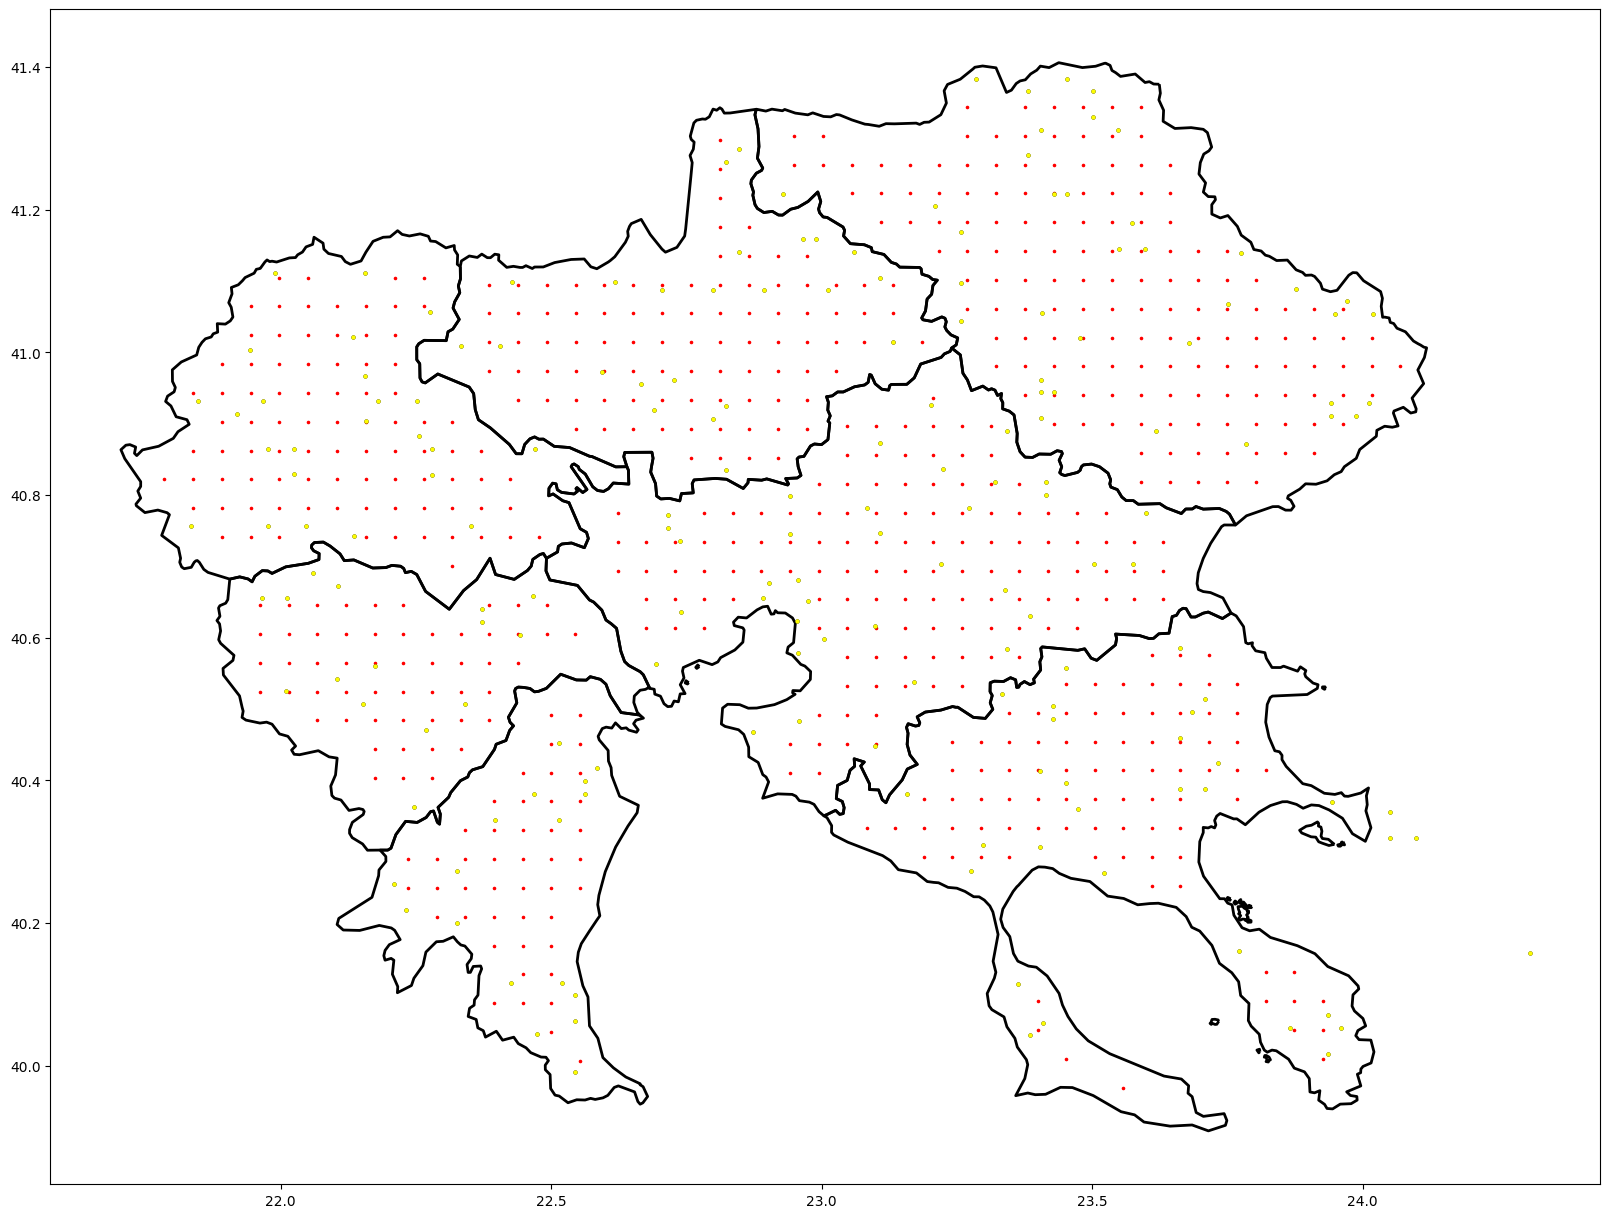

In [24]:
ax = nuts2_gdf.plot(facecolor="none", edgecolor='black',lw=2, figsize=(20, 20))
nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red', ax=ax)
geo_points.plot(markersize=4.5, figsize=(20, 20), color='black', ax=ax)
lc_points.plot(markersize=4.5, figsize=(20, 20), color='yellow', ax=ax)